# Feature detection

## Harris Corner detection

As always we start with the imports

In [26]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

To start, we will use the same checkerboard image as earlier.

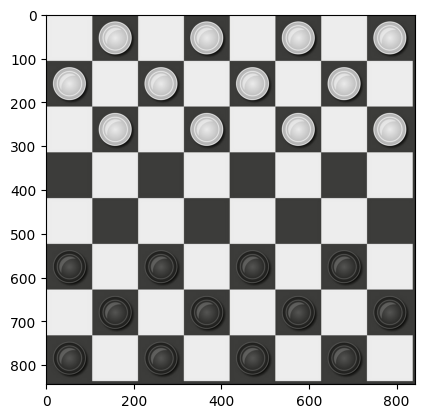

In [27]:
img = cv2.imread('checkers.png')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2a
Fill in the missing code in the next block. We would like to detect the corners of the image using the OpenCV function [`cv2.cornerHarris`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#gac1fc3598018010880e370e2f709b4345). Afterwards we want to draw the location of the detected corners on the image and display it.

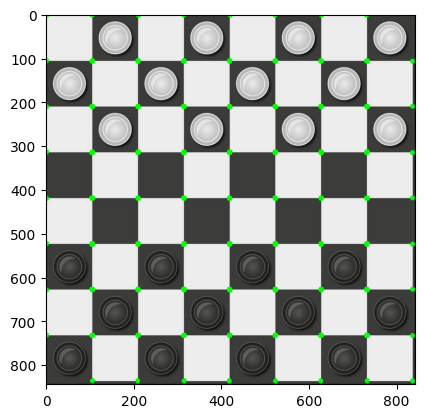

In [28]:
# Change image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = np.float32(gray)

### Insert Harris Corner detector here ###
dst = cv2.cornerHarris(gray, 5, 3, 0.04)# (image
                                        #  Es el tamaño de la "ventana" o bloque de píxeles que el algoritmo analiza al mismo tiempo para decidir si hay una esquina.
                                        #  Debe ser un número impar entre 1 y 31
                                        #  El número k es un ajustador arbitrario en esa fórmula, empíricamente establecido entre 0.04 y 0.06.
### Draw the detected corners in the original image here ###
puntuacion_maxima = dst.max()
umbral = 0.01 * puntuacion_maxima
coordenadas_y, coordenadas_x = np.where(dst > umbral)
for i in range(len(coordenadas_x)):
    x = coordenadas_x[i]
    y = coordenadas_y[i]
    cv2.circle(img, (x, y), 3, (0, 255, 0), -1)
#img[dst > 0.01 * dst.max()] = [0, 255, 0]
# Display image
plt. imshow(img)

## Shi-Tomasi
Next we will try the Shi-Tomasi feature detection method. In OpenCV, that method is implemented as [`cv2.goodFeaturesToTrack`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga1d6bb77486c8f92d79c8793ad995d541). 
Let's start with a different image this time.

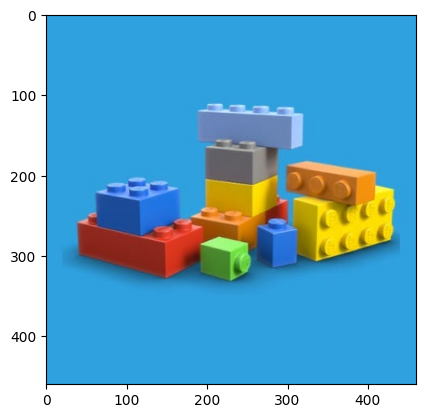

In [11]:
img = cv2.imread('Lego.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

### Exercise 2b
Just like the previous exercise, detect the corners of the image by inserting the missing code, this time using the Shi-Tomasi (good features to track) method. Draw the detected corners on the image. Check the documentation of the function for help.

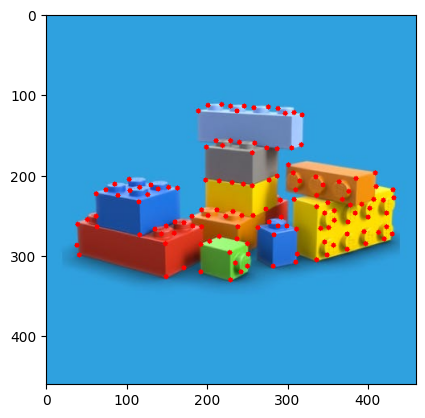

In [17]:
# Change image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

### Insert goodFeaturesToTrack detector here ###
corners =  cv2.goodFeaturesToTrack(gray, 0, 0.01, 10)
if corners is not None:
    # Convertir las coordenadas a enteros para poder dibujarlas
    corners = np.int32(corners)
### Draw the detected corners in the original image here ###
for i in corners:
        # i se ve así: [[x, y]]
        # i[0] abre el corchete exterior y te da: [x, y]
        
        x = i[0][0]  # El primer número (posición 0) es la X
        y = i[0][1]  # El segundo número (posición 1) es la Y
        
        cv2.circle(img, (x, y), 3, (255, 0, 0), -1)

# Display image
plt. imshow(img)

### Exercise 2c
Do a Harris corner detection on the same Lego image and compare the result with the Shi-Tomasi image.

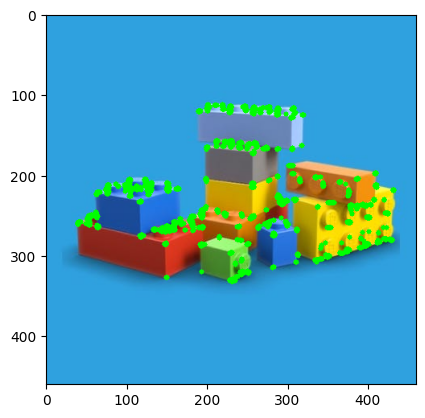

In [43]:
img = cv2.imread('Lego.jpg')
# Changing the order from bgr to rgb so that matplotlib can show it
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

# Change image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = np.float32(gray)

### Insert Harris Corner detector here ###
dst = cv2.cornerHarris(gray, 2, 3, 0.04)# (image
                                        #  Es el tamaño de la "ventana" o bloque de píxeles que el algoritmo analiza al mismo tiempo para decidir si hay una esquina.
                                        #  Debe ser un número impar entre 1 y 31
                                        #  El número k es un ajustador arbitrario en esa fórmula, empíricamente establecido entre 0.04 y 0.06.
### Draw the detected corners in the original image here ###
puntuacion_maxima = dst.max()
umbral = 0.001 * puntuacion_maxima
coordenadas_y, coordenadas_x = np.where(dst > umbral)
for i in range(len(coordenadas_x)):
    x = coordenadas_x[i]
    y = coordenadas_y[i]
    cv2.circle(img, (x, y), 3, (0, 255, 0), -1)
# Display image
plt. imshow(img)